In [128]:
import os
import seaborn as sns
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import imagehash
from IPython.display import clear_output
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from transformers import ViTImageProcessor, ViTModel
from PIL import Image
import requests
from torchvision import transforms as T
from skimage.transform import rescale, resize
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd  # If your data is in a pandas DataFrame
import seaborn as sns # For potentially nicer plots

In [2]:
folder = r"C:\Users\Siema\Documents\projekt 2 ml\projekt 2\jellyfish_ML\data"
global_file_count = 0
skip_dirnames = ["Train_Test_Valid","augmented","augemented"]
extension_list = []
images = []
for root, dirs, files in os.walk(folder):
    print(root)
    dirs[:] = [d for d in dirs if d not in skip_dirnames]
    for file in files:
        extension_list.append(file.split(".")[-1])
        images.append(plt.imread(os.path.join(root,file)))
        global_file_count = global_file_count + 1

print("-----------------------------")
print(global_file_count)
    
images = np.array(images,dtype=object)

C:\Users\Siema\Documents\projekt 2 ml\projekt 2\jellyfish_ML\data
C:\Users\Siema\Documents\projekt 2 ml\projekt 2\jellyfish_ML\data\barrel_jellyfish
C:\Users\Siema\Documents\projekt 2 ml\projekt 2\jellyfish_ML\data\blue_jellyfish
C:\Users\Siema\Documents\projekt 2 ml\projekt 2\jellyfish_ML\data\compass_jellyfish
C:\Users\Siema\Documents\projekt 2 ml\projekt 2\jellyfish_ML\data\lions_mane_jellyfish
C:\Users\Siema\Documents\projekt 2 ml\projekt 2\jellyfish_ML\data\mauve_stinger_jellyfish
C:\Users\Siema\Documents\projekt 2 ml\projekt 2\jellyfish_ML\data\Moon_jellyfish
-----------------------------
900


<Axes: ylabel='Count'>

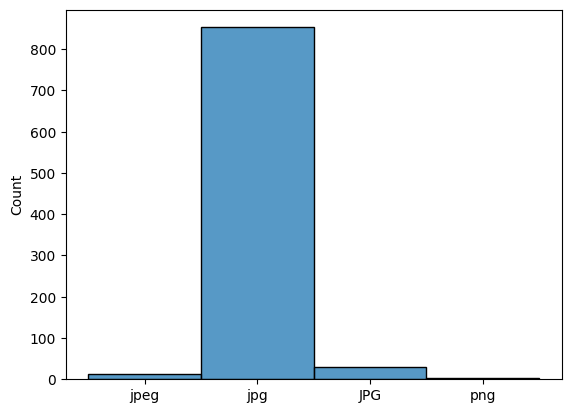

In [3]:
sns.histplot(extension_list)

all of the files are images

In [4]:
import hashlib
def hash_image(image_path, hunk_size = 8192):
    h = hashlib.new('md5')
    with open(image_path, 'rb') as f:
        while True:
            hunk = f.read(hunk_size)
            if hunk==b'':
                return h.hexdigest()
            h.update(hunk)


path= Path(r"C:\Users\Siema\Documents\projekt 2 ml\projekt 2\jellyfish_ML/data/Train_Test_Valid")
file_count = 0
hashes_ttv = set()
skip_dirs = []
for root, dirnames, filenames in os.walk(path):
    dirnames[:] = [d for d in dirnames if d not in skip_dirs]
    for file in filenames:
        file_count = file_count +1
        hashes_ttv.add( hash_image( os.path.join(root,file) ) )
print(file_count)
print(len(hashes_ttv))



979
979


In [5]:
path= Path(r"C:\Users\Siema\Documents\projekt 2 ml\projekt 2\jellyfish_ML/data")
file_count = 0  
hashes_rest = set()
skip_dirs = ["Train_Test_Valid","augmented","augemented"]
for root, dirnames, filenames in os.walk(path):
    dirnames[:] = [d for d in dirnames if d not in skip_dirs]
    for file in filenames:
        file_count = file_count +1
        hashes_rest.add( hash_image( os.path.join(root,file) ) )
print(file_count)
print(len(hashes_rest))


900
900


There is no duplicates

In [6]:
for elem in hashes_rest:
    hashes_ttv.add(elem)

print(len(hashes_ttv))

979


everything that is in data directory not not in Train_Test_Valid is also in Train_Test_Valid

In [7]:
print(len(hashes_rest))
train_file_count = 0
path = Path(r"C:\Users\Siema\Documents\projekt 2 ml\projekt 2\jellyfish_ML/data/Train_Test_Valid\Train")
for root, dirnames, filenames in os.walk(path):
    for file in filenames:
        train_file_count = train_file_count + 1
        hashes_rest.add( hash_image( os.path.join(root,file) ) )

print(train_file_count)
print(len(hashes_rest))

900
900
900


every image in data outside of Train_Test_Valid directory is also in Train_Test_Valid/Train directory

<Axes: >

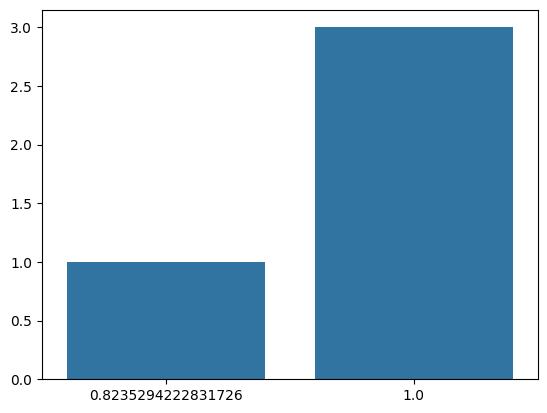

In [8]:


arr_temp = np.zeros(len(images))
for i in range(len(images)):
    arr_temp[i] = images[i].max()

scaled_img_idx = np.array(range(len(arr_temp)))[arr_temp<140] #!!!
arr_temp = arr_temp[arr_temp<140]
counter_temp = Counter(arr_temp)
values = counter_temp.values()
keys = counter_temp.keys()
sns.barplot(x=keys, y = values)

4 of the images are scaled to <0,1> range. We will rescale them.

In [9]:
rescaled_images = images[scaled_img_idx]*255
for i in range(len(rescaled_images)):
    rescaled_images[i] = rescaled_images[i].astype(np.uint8)

images[scaled_img_idx] = rescaled_images

<Axes: >

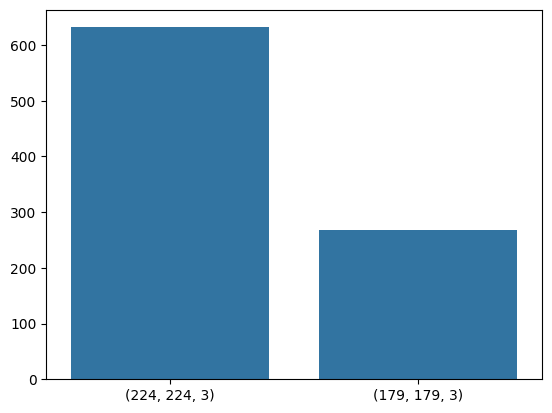

In [12]:
path = r"C:\Users\Siema\Documents\projekt 2 ml\projekt 2\jellyfish_ML\data\Train_Test_Valid\Train"
i=0
species =[]
for root, dirnames, filenames in os.walk(path):
    for file in filenames:
        img_path = os.path.join(root,file)
        i=i+1
        species.append(os.path.basename(os.path.normpath(root)))


shapes = np.empty(train_file_count,dtype=object)
i=0
for img in images:
    shapes[i] = img.shape
    i=i+1

counter = Counter(shapes)
names = list(counter.keys())
for i in range(len(names)):
    names[i] = str(names[i])
values = list(counter.values())

sns.barplot(x = names, y = values)

In [13]:
index_to_resize = []
for i in range(len (images)):
    if(images[i].shape != (224,224,3)):
        index_to_resize.append(i)

images_resized = []
for i in index_to_resize:
    images_resized.append(resize(images[i], (224,224,3),anti_aliasing=True))

for i in range(len(images_resized)):
    temp = images_resized[i] * 255
    temp = temp.round()
    temp = temp.astype(np.uint8)
    images_resized[i] = temp

images[index_to_resize] = images_resized
    


In [ ]:
images_model = [0 for i in range(len(images))]
for i in range(len(images)):
    images_model[i] = Image.fromarray(images[i])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [ ]:
# 1. Pipeline augmentacji offline (bez Normalize)
offline_augment = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomRotation(degrees=30),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, 
                  saturation=0.2, hue=0.05),
    T.ToTensor(),                    # potrzebne, by RandomErasing działał
    T.RandomErasing(p=0.3, scale=(0.02, 0.05), value='random'),
    T.ToPILImage()                   
])

path = Path(r"C:\Users\Siema\Documents\projekt 2 ml\projekt 2\jellyfish_ML\data")
dst_dir    = path / "augemented" /"train"  # katalog na wygenerowane pliki
dst_dir.mkdir(parents=True, exist_ok=True)
num_copies = 5  

j = 0
species_change = 150
species_name_idx = -1
aug_images = []
aug_species = []
species_names = [species[0+150*i] for i in range(6)]
img_idx = 0
for img in images_model:
    if(img_idx%150 == 0):
        species_name_idx+=1
    img_idx+=1
    for i in range(5):
        aug_img = offline_augment(img)
        aug_path = dst_dir / f"augmented_{j}.jpg"
        j+=1
        aug_img.save(aug_path)
        aug_images.append(aug_img)
        aug_species.append(species_names[species_name_idx])


In [16]:
aug_images.extend(list(images_model))
aug_species.extend(species)

In [18]:
from transformers import ViTImageProcessor, ViTModel
import torch

features = []
batch_size = 1
# 1. load the ViT processor & model
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')
model     = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k').eval()

# move to GPU if you have one
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for i in range(0, len(aug_images),batch_size):
    batch = aug_images[i:i+batch_size]
    inputs = processor(images=batch, return_tensors="pt").to(device)
    outputs = model(**inputs)
    cls_emb = outputs.last_hidden_state[:,0,:]
    new_features = cls_emb.squeeze(0).detach().cpu().numpy()  
    features.append(new_features)
    

----------------------------------------------------------------------------------------------------------------

In [19]:
# path = r"C:\Users\Kacper\Documents\iad semestr 4\ML\projekt 2\jellyfish_ML\data\Train_Test_Valid\Train"
# path_hash = {}
# path_image = {}
# for root, dirnames, filenames in os.walk(path):
#     for f in filenames:
#         image_path = os.path.join(root,f)
#         path_hash[image_path] = imagehash.phash(Image.open(os.path.join(root,f)), hash_size=16)
#         path_image[image_path] = Image.open(image_path)

# threshold = 10
# if_first_copy = True
# path_copy_path= {}
# checked_paths = []
# for p_o in path_image.keys():
#     checked_paths.append(p_o)
#     original_hash = path_hash[p_o]
#     for p in path_image.keys():
#         if p in checked_paths:
#             continue
#         if (original_hash-path_hash[p])<threshold:
#             if if_first_copy:
#                 path_copy_path[p_o] = list()
#             path_copy_path[p_o].append(p)







In [20]:
# for p_original, c_list in path_copy_path.items():
#     print(f"original: {p_original}")
#     display(path_image[p_original])
#     print("copies:")
#     for i in range(len(c_list)):
#         print(f"{i} {c_list[i]}" )
#         display(path_image[c_list[i]])
#     input()
#     clear_output()
    

----------------------------------------------------------------------------------------------------------------

In [21]:
features = np.array(features)
df_features= pd.DataFrame(features)

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

k = 6
kmeans = KMeans(
    n_clusters=k,
    init='k-means++',     # smart initialization
    n_init=10,            # number of random restarts
    max_iter=300,         # max iterations per run
    tol=1e-4,             # convergence tolerance
    random_state=42
)

kmeans.fit(features_scaled)

KMeans(n_clusters=6, n_init=10, random_state=42)

In [23]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
species_int=le.fit_transform(aug_species)

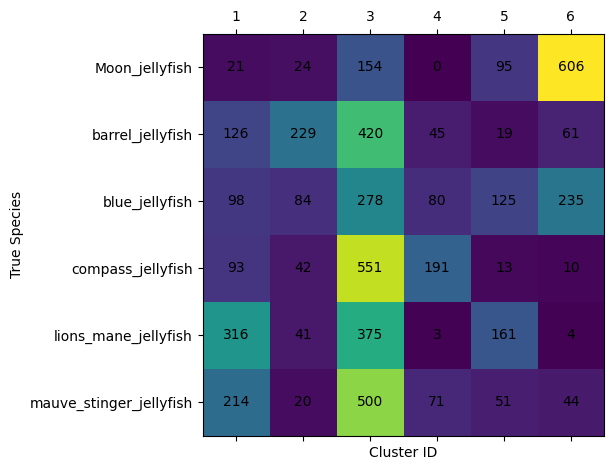

In [24]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics       import confusion_matrix
import matplotlib.pyplot    as plt
import numpy as np
y_pred = kmeans.predict(features_scaled)

cm = confusion_matrix(species_int,y_pred)

fig, ax = plt.subplots()
cax = ax.matshow(cm)
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, val, ha='center', va='center')
ax.set_xticks(np.arange(len(le.classes_)))
ax.set_xticklabels(list(range(1,7)))
ax.set_yticks(np.arange(len(le.classes_)))
ax.set_yticklabels(le.classes_)
ax.set_xlabel('Cluster ID')
ax.set_ylabel('True Species')
plt.tight_layout()
plt.show()

In [25]:
def scale_to_01(image):
    
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val > min_val:
        scaled_array = (image - min_val) / (max_val - min_val)
    else:
        # Handle the case where all pixel values are the same
        scaled_array = np.zeros_like(image_, dtype=np.float32)
    return scaled_array.astype(np.float32)

gray_aug_images = np.array([np.asarray(img.convert("L")) for img in aug_images])
scaled_gray_aug_images = []
for img in gray_aug_images:
    scaled_gray_aug_images.append( scale_to_01(img) )

In [26]:
import numpy as np
from scipy import signal
from skimage.filters import gabor_kernel
from PIL import Image

def compute_gabor_features(image, kernels):
    features = []
    for kernel in kernels:
        # Convolve the image with the real part of the Gabor kernel
        filtered_real = signal.convolve2d(image, np.real(kernel), mode='same')
        features.extend([np.mean(filtered_real), np.std(filtered_real)])
    return np.array(features)

def create_gabor_filter_bank(frequencies, orientations):
    kernels = []
    for frequency in frequencies:
        for theta in np.arange(0, np.pi, np.pi / orientations):
            kernel = gabor_kernel(frequency, theta=theta, sigma_x=None, sigma_y=None, n_stds=3)
            kernels.append(kernel)
    return kernels

def process_image_array(image_array, frequencies, orientations):
    
    kernels = create_gabor_filter_bank(frequencies, orientations)
    all_features = []
    i=1
    for image in image_array:
        features = compute_gabor_features(image, kernels)
        all_features.append(features)
        print(f"{i} done")
        if(i%100 == 0):
            print(f"{i} done")
        i+=1
        
    return np.array(all_features)


frequencies = [0.1, 0.4]
orientations = 4

gabor_featres = process_image_array(scaled_gray_aug_images,frequencies, orientations)

1 done
2 done
3 done
4 done
5 done
6 done
7 done
8 done
9 done
10 done
11 done
12 done
13 done
14 done
15 done
16 done
17 done
18 done
19 done
20 done
21 done
22 done
23 done
24 done
25 done
26 done
27 done
28 done
29 done
30 done
31 done
32 done
33 done
34 done
35 done
36 done
37 done
38 done
39 done
40 done
41 done
42 done
43 done
44 done
45 done
46 done
47 done
48 done
49 done
50 done
51 done
52 done
53 done
54 done
55 done
56 done
57 done
58 done
59 done
60 done
61 done
62 done
63 done
64 done
65 done
66 done
67 done
68 done
69 done
70 done
71 done
72 done
73 done
74 done
75 done
76 done
77 done
78 done
79 done
80 done
81 done
82 done
83 done
84 done
85 done
86 done
87 done
88 done
89 done
90 done
91 done
92 done
93 done
94 done
95 done
96 done
97 done
98 done
99 done
100 done
100 done
101 done
102 done
103 done
104 done
105 done
106 done
107 done
108 done
109 done
110 done
111 done
112 done
113 done
114 done
115 done
116 done
117 done
118 done
119 done
120 done
121 done
122 done
1

In [28]:
from skimage.feature import graycomatrix, graycoprops

def calculate_haralick_features(image, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=256, symmetric=True, normed=True):
    if levels < 256:
        image = (image / (256 // levels)).astype(np.uint8)

    glcm = graycomatrix(image, distances=distances, angles=angles, levels=levels, symmetric=symmetric, normed=normed)

    features = {}
    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    for prop in props:
        feature_values = graycoprops(glcm, prop)
        # Average the feature values over all angles
        features[prop] = np.mean(feature_values)

    return features

def process_image_array_haralick(image_array, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=256, symmetric=True, normed=True):
    all_features = []
    i=1
    for image in image_array:
        features = calculate_haralick_features(image, distances, angles, levels, symmetric, normed)
        all_features.append(list(features.values()))
        print(f"{i} done")
        i+=1
    return np.array(all_features)

scaled_gray_aug_images_temp = []
for img in scaled_gray_aug_images:
    img = img *255
    img = img.astype(np.uint8)
    scaled_gray_aug_images_temp.append(img)

haralic_features = process_image_array_haralick(scaled_gray_aug_images_temp)

1 done
2 done
3 done
4 done
5 done
6 done
7 done
8 done
9 done
10 done
11 done
12 done
13 done
14 done
15 done
16 done
17 done
18 done
19 done
20 done
21 done
22 done
23 done
24 done
25 done
26 done
27 done
28 done
29 done
30 done
31 done
32 done
33 done
34 done
35 done
36 done
37 done
38 done
39 done
40 done
41 done
42 done
43 done
44 done
45 done
46 done
47 done
48 done
49 done
50 done
51 done
52 done
53 done
54 done
55 done
56 done
57 done
58 done
59 done
60 done
61 done
62 done
63 done
64 done
65 done
66 done
67 done
68 done
69 done
70 done
71 done
72 done
73 done
74 done
75 done
76 done
77 done
78 done
79 done
80 done
81 done
82 done
83 done
84 done
85 done
86 done
87 done
88 done
89 done
90 done
91 done
92 done
93 done
94 done
95 done
96 done
97 done
98 done
99 done
100 done
101 done
102 done
103 done
104 done
105 done
106 done
107 done
108 done
109 done
110 done
111 done
112 done
113 done
114 done
115 done
116 done
117 done
118 done
119 done
120 done
121 done
122 done
123 done
1

In [ ]:
df_haralic = pd.DataFrame([ *haralic_features])
df_gabor = pd.DataFrame([*gabor_featres])

<Axes: ylabel='Count'>

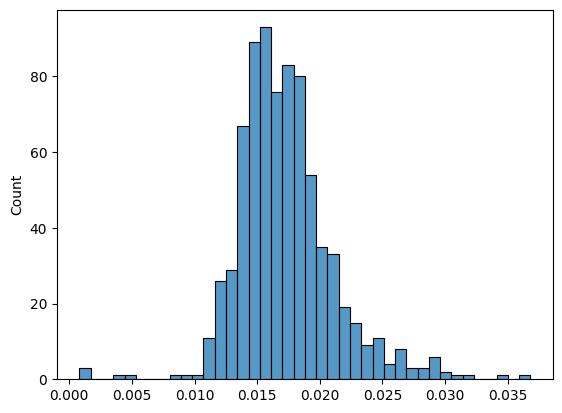

In [56]:
ViT_variance = df_features.var(axis= 0)
sns.histplot(ViT_variance)

In [67]:
df_features_temp = df_features.loc[:, ViT_variance>=0.005]

In [70]:
df_features_all = pd.concat([df_features_temp, df_gabor, df_haralic], axis = 1)

In [85]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_features_all)

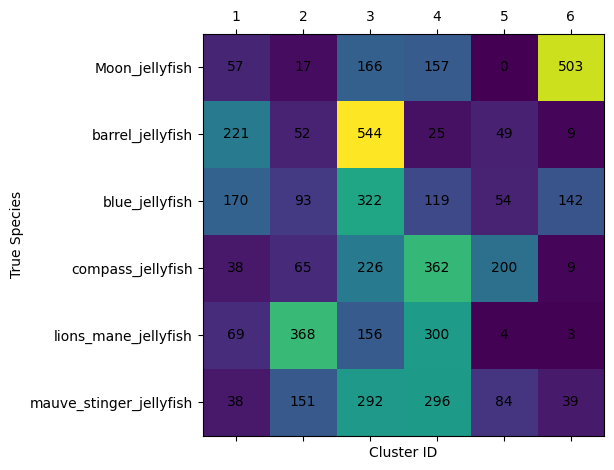

In [155]:
species_int=le.fit_transform(aug_species)

kmeans.fit(scaled_features)
y_pred = kmeans.predict(scaled_features)
cm = confusion_matrix(species_int,y_pred)

fig, ax = plt.subplots()
cax = ax.matshow(cm)
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, val, ha='center', va='center')
ax.set_xticks(np.arange(len(le.classes_)))
ax.set_xticklabels(list(range(1,7)))
ax.set_yticks(np.arange(len(le.classes_)))
ax.set_yticklabels(le.classes_)
ax.set_xlabel('Cluster ID')
ax.set_ylabel('True Species')
plt.tight_layout()
plt.show()





Wyjaśniony współczynnik wariancji dla każdego komponentu: [1.00235988e-01 4.87837413e-02 3.75425658e-02 3.44781784e-02
 2.78469851e-02 2.37233977e-02 2.23167516e-02 2.13203046e-02
 1.72481470e-02 1.59625952e-02 1.44448253e-02 1.35466462e-02
 1.21177102e-02 1.17992512e-02 1.07339214e-02 1.01125907e-02
 9.74242792e-03 9.28172120e-03 8.84063341e-03 8.50717732e-03
 8.13679512e-03 7.83836315e-03 7.49369579e-03 7.28944104e-03
 6.95447502e-03 6.56533195e-03 6.41257013e-03 6.06246971e-03
 5.95367071e-03 5.80753290e-03 5.66534436e-03 5.59411769e-03
 5.40193549e-03 5.36839327e-03 5.19520636e-03 5.07431861e-03
 4.99402410e-03 4.76880080e-03 4.73126269e-03 4.59317815e-03
 4.46651964e-03 4.38957636e-03 4.32436882e-03 4.26076892e-03
 4.09708420e-03 4.02904545e-03 3.90671603e-03 3.84628457e-03
 3.83032217e-03 3.72581323e-03 3.66730998e-03 3.64447843e-03
 3.59862840e-03 3.44099694e-03 3.35091558e-03 3.27973333e-03
 3.20405365e-03 3.15971428e-03 3.11992540e-03 3.09670085e-03
 3.01095742e-03 2.98783563e

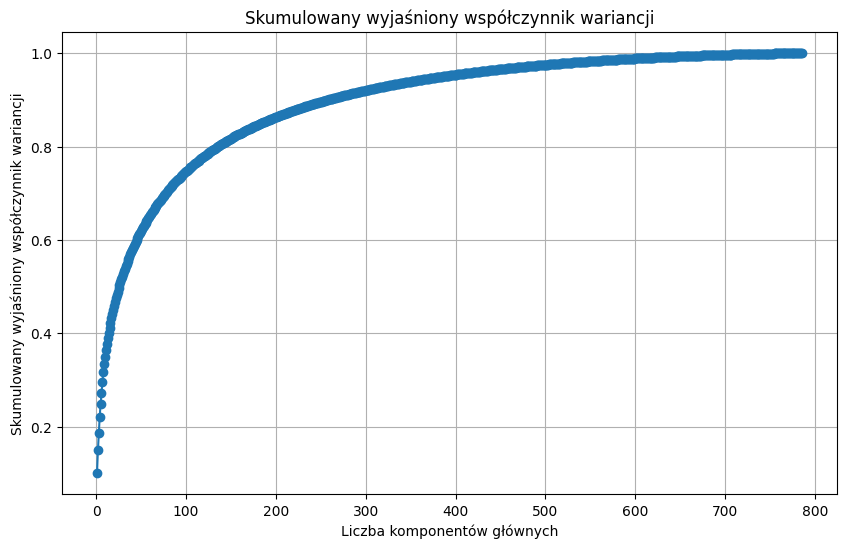

In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(scaled_features)
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Wizualizacja wyjaśnionej wariancji
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-')
plt.title('Skumulowany wyjaśniony współczynnik wariancji')
plt.xlabel('Liczba komponentów głównych')
plt.ylabel('Skumulowany wyjaśniony współczynnik wariancji')
plt.grid(True)
plt.show()


In [140]:
k = 200
components = pca.transform(scaled_features)[:,:k]

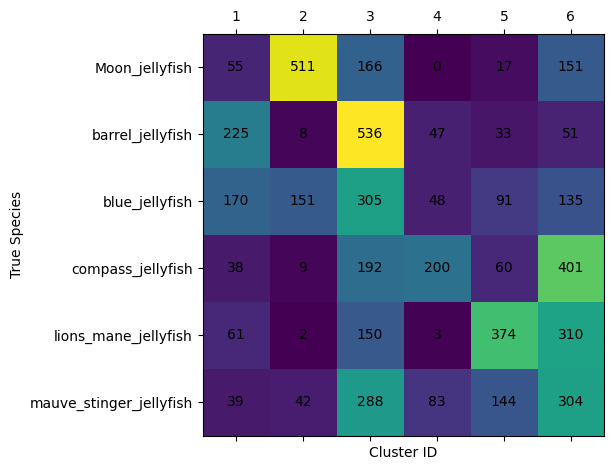

In [141]:
species_int=le.fit_transform(aug_species)

kmeans.fit(components)

y_pred = kmeans.predict(components)

cm = confusion_matrix(species_int,y_pred)


fig, ax = plt.subplots()
cax = ax.matshow(cm)
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, val, ha='center', va='center')
ax.set_xticks(np.arange(len(le.classes_)))
ax.set_xticklabels(list(range(1,7)))
ax.set_yticks(np.arange(len(le.classes_)))
ax.set_yticklabels(le.classes_)
ax.set_xlabel('Cluster ID')
ax.set_ylabel('True Species')
plt.tight_layout()
plt.show()


c:\Users\Siema\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Siema\AppData\Local\Temp\ipykernel_39600\2783379174.py:3: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  labels_numerical_pandas, unique_labels_pandas = pd.factorize(aug_species)


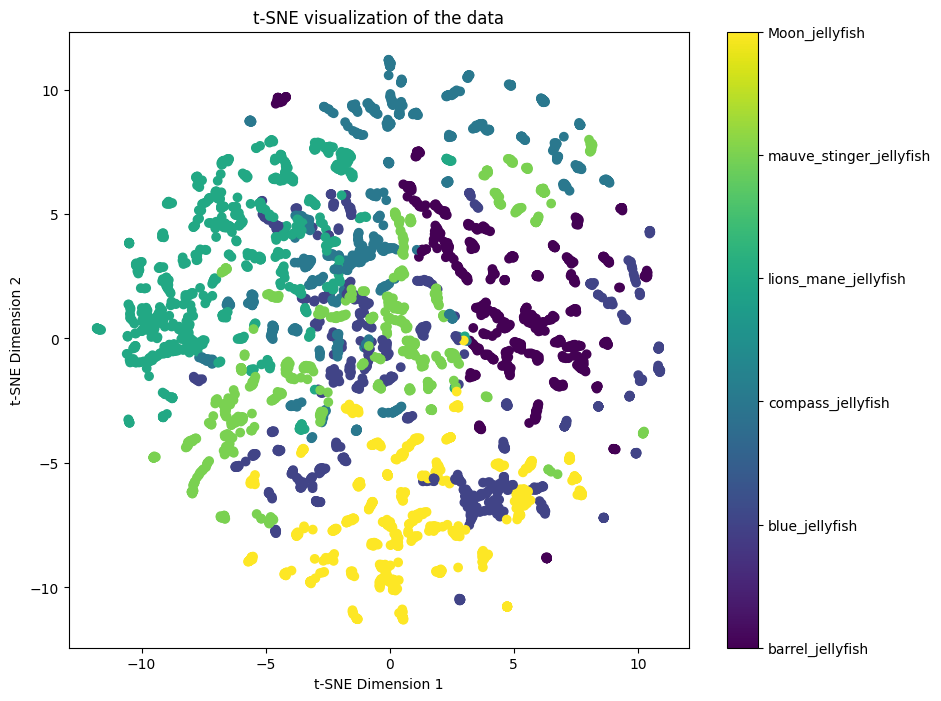

In [147]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)
X = tsne.fit_transform(components)
labels_numerical_pandas, unique_labels_pandas = pd.factorize(aug_species)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels_numerical_pandas, cmap='viridis')
cbar = plt.colorbar(scatter, ticks=np.arange(len(unique_labels_pandas)))
cbar.ax.set_yticklabels(unique_labels_pandas)
plt.title('t-SNE visualization of the data')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()